# 🧭 Capstone Template — Time Series Forecasting

**Rename this file before you start:** `time_series_name_surname.ipynb`  
Example: `electricity_demand_ameena_khan.ipynb`

Use this notebook to complete your capstone. It is the **only** notebook you will submit in the final deliverable.

---

## How to use this template

- Work **top to bottom**, filling in the prompts and running the code cells.   
- Most steps include **“TODO” prompts** — replace them with your notes.
- If you need a package (e.g., `statsmodels`), install it in your environment once (see the install cell).

---

## Project summary (fill as you go)

- **Dataset title/source:**  Boknis Eck Timeseries / GEOMAR (https://timeseries.geomar.de/boknis/app/)

- **Target to forecast (variable & unit):** temperature (°C) 

- **Cadence (e.g., daily, monthly) and date range:** Mean cadence is ~15 days. Range: 1957-05-14 to 2023-03-14.

- **Forecast horizon `H` (e.g., next 12 months):** 12 months (24 periods of 15 days).  

- **Why this matters (impact/context):** The Boknis Eck time series is one of the longest continuous marine time series in the Baltic Sea. Accurate forecasting helps quantifty long-term trends against natural variability, which is crucial for monitoring ecosystem health and detecting climate change anomalies.  

- **Stakeholder decisions enabled by this forecast:**  Scientific validation of climate models, assessment of potential biological shifts (e.g., species migration due to warming), and informing local environmental policy regarding marine protection.

- **Known caveats:**
  - **4-year data gap (1979-1983):** Filled using Seasonal Anomaly Interpolation to preserve winter/summer cycles. This introduces uncertainty in trend estimates for that period.
  - **Measurement depth:** All observations are at ~10m depth; results may not generalize to other depths.
  - **Irregular original cadence:** Raw data had variable intervals (~7-30 days); resampled to regular 15-day frequency.


In [778]:
# Optional: install dependencies (uncomment if needed)
# %pip install -q pandas matplotlib numpy statsmodels scikit-learn


In [779]:
pip install notebook pandas matplotlib numpy statsmodels scikit-learn

Python(20861) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [780]:
# --- Imports & defaults ---
try:
    import numpy as np
except ModuleNotFoundError:
    # Uncomment the following line to install numpy if not already installed
    # %pip install numpy
    raise
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

from sklearn.metrics import mean_absolute_error
from pandas.tseries.frequencies import to_offset



## 1) Data loading & provenance

**Goal:** load your dataset, identify the date/time column and the target variable, and create a clean `Series` (or single-column `DataFrame`) indexed by time.

> Place your CSV in the **same folder** as this notebook, or set an explicit path.


In [781]:
import pandas as pd

# Load the CSV file and parse dates (but do not set index yet)
df = pd.read_csv("boknis_eck.csv", parse_dates=["phenomenonTime"])

# Format the 'phenomenonTime' column to 'YYYY-MM-DD' string
df['phenomenonTime'] = df['phenomenonTime'].dt.strftime('%Y-%m-%d')

# Set the formatted column as the index
df.set_index('phenomenonTime', inplace=True)

# Rename the index to "Date"
df.index.name = "Date"

# Convert index to datetime objects again so pandas treats it as time-series data
# (Formatting to string earlier is useful for display, but for analysis a DatetimeIndex is usually required)
df.index = pd.to_datetime(df.index)

# Display the first few rows
print(df.head())
print(df.info())


            water depth (m)  CTD temperature (°C)
Date                                             
1957-05-14             10.0                   7.2
1957-06-04             10.0                  10.2
1957-06-14             10.0                  12.6
1957-07-05             10.0                  11.0
1957-07-30             10.0                  16.3
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1542 entries, 1957-05-14 to 2023-03-20
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   water depth (m)       1542 non-null   float64
 1   CTD temperature (°C)  1542 non-null   float64
dtypes: float64(2)
memory usage: 36.1 KB
None


In [782]:
# Inspect values present in the "water depth (m)" column
col = "water depth (m)"
s = df[col]

print(f"Column: {col}")
print("dtype:", s.dtype)
print("non-null count:", s.count(), "/", len(s))
print("unique count:", s.nunique())

# If there are few distinct values, show them all; otherwise show top counts
if s.nunique() <= 50:
    print("unique values (sorted):", sorted(s.unique()))
else:
    print("Top value counts:")
    print(s.value_counts().head(20))

# Summary statistics
print("\nSummary stats:")
print("min:", s.min(), "max:", s.max(), "mean:", s.mean(), "median:", s.median(), "std:", s.std())

# Check for non-finite / missing / unusual entries
bad = s[~np.isfinite(s)]
if len(bad):
    print("\nNon-finite values (index -> value):")
    print(bad)
else:
    print("\nAll values are finite numeric.")

# Highlight if the column is constant
if s.nunique() == 1:
    print(f"\nColumn is constant: all rows have value = {s.iloc[0]}")

# Show a concise frequency table (up to 20 unique values)
print("\nValue counts (up to 20):")
print(s.value_counts().head(20))

Column: water depth (m)
dtype: float64
non-null count: 1542 / 1542
unique count: 6
unique values (sorted): [np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0)]

Summary stats:
min: 7.0 max: 12.0 mean: 9.994163424124514 median: 10.0 std: 0.20211000984265654

All values are finite numeric.

Value counts (up to 20):
water depth (m)
10.0    1519
9.0       10
12.0       5
8.0        3
11.0       3
7.0        2
Name: count, dtype: int64


The depth of the very most observations is 10 meters. The very few outliers should not impact the outcome. That's why I drop the column "water depth (m)".

In [783]:
# Drop the 'water depth (m)' column from df (inplace) and show result
if 'water depth (m)' in df.columns:
    df.drop(columns=['water depth (m)'], inplace=True)
    print("Dropped column: 'water depth (m)'\n")
else:
    print("Column 'water depth (m)' not found in df\n")

print(df.head())
print("\nDataFrame info:")
print(df.info())

Dropped column: 'water depth (m)'

            CTD temperature (°C)
Date                            
1957-05-14                   7.2
1957-06-04                  10.2
1957-06-14                  12.6
1957-07-05                  11.0
1957-07-30                  16.3

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1542 entries, 1957-05-14 to 2023-03-20
Data columns (total 1 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CTD temperature (°C)  1542 non-null   float64
dtypes: float64(1)
memory usage: 24.1 KB
None


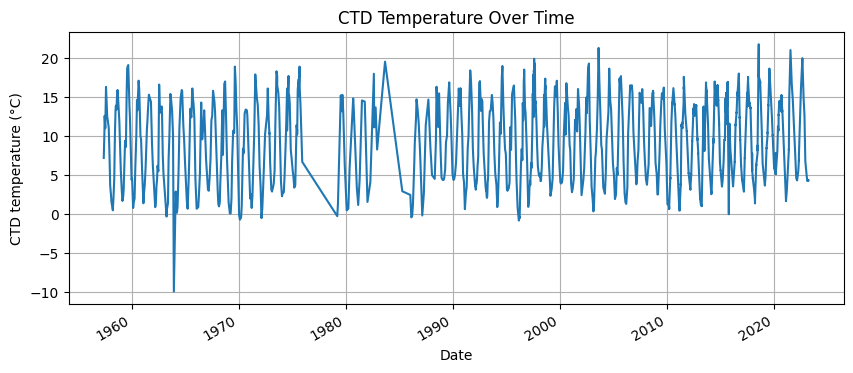

In [784]:
df["CTD temperature (°C)"].plot(title='CTD Temperature Over Time', figsize=(10, 4))
plt.ylabel('CTD temperature (°C)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

In [785]:
monthly = df.resample('M').mean()
print(monthly.head())

            CTD temperature (°C)
Date                            
1957-05-31                  7.20
1957-06-30                 11.40
1957-07-31                 13.65
1957-08-31                   NaN
1957-09-30                 12.50


The mean cadence is: 15 days 14:34:39.169370538
First 10 time differences:
Date
1957-05-14       NaT
1957-06-04   21 days
1957-06-14   10 days
1957-07-05   21 days
1957-07-30   25 days
1957-09-09   41 days
1957-10-31   52 days
1957-11-07    7 days
1957-11-28   21 days
1957-12-19   21 days
Name: time_diff, dtype: timedelta64[ns]

Statistical summary of the time differences:
count                          1541
mean     15 days 14:34:39.169370538
std      39 days 13:15:45.277496004
min                 0 days 00:00:00
25%                 0 days 00:00:00
50%                 0 days 00:00:00
75%                28 days 00:00:00
max              1196 days 00:00:00
Name: time_diff, dtype: object


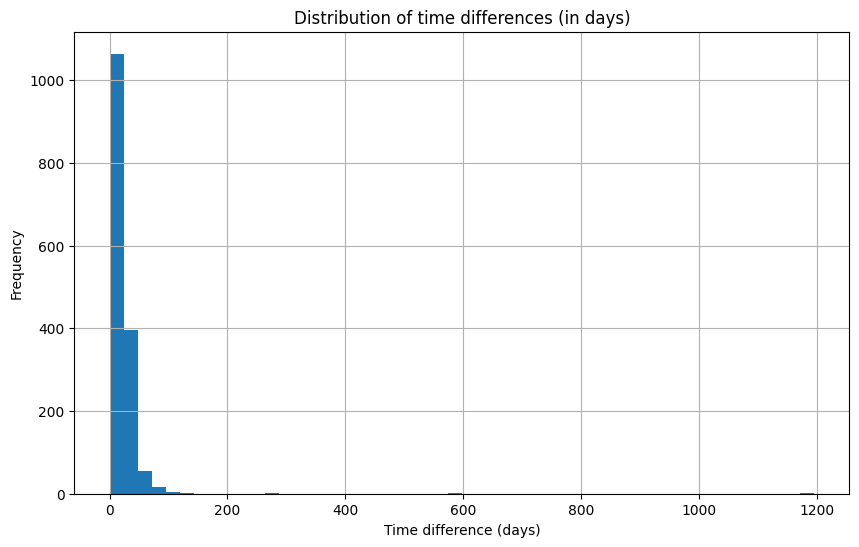

In [786]:
# Calculate the differences between the timestamps
df["time_diff"] = df.index.to_series().diff()

# Calculate the average cadence
average_cadence = df["time_diff"].mean()
print("The mean cadence is:", average_cadence)

# Show the first 10 differences
print("First 10 time differences:")
print(df["time_diff"].head(10))

# Statistical summary of the time differences
print("\nStatistical summary of the time differences:")
print(df["time_diff"].describe())

# Visualize the distribution of time differences
import matplotlib.pyplot as plt

# Visualize the distribution of time differences in days
plt.figure(figsize=(10, 6))
df["time_diff"].dt.days.dropna().hist(bins=50)
plt.title("Distribution of time differences (in days)")
plt.xlabel("Time difference (days)")
plt.ylabel("Frequency")
plt.show()

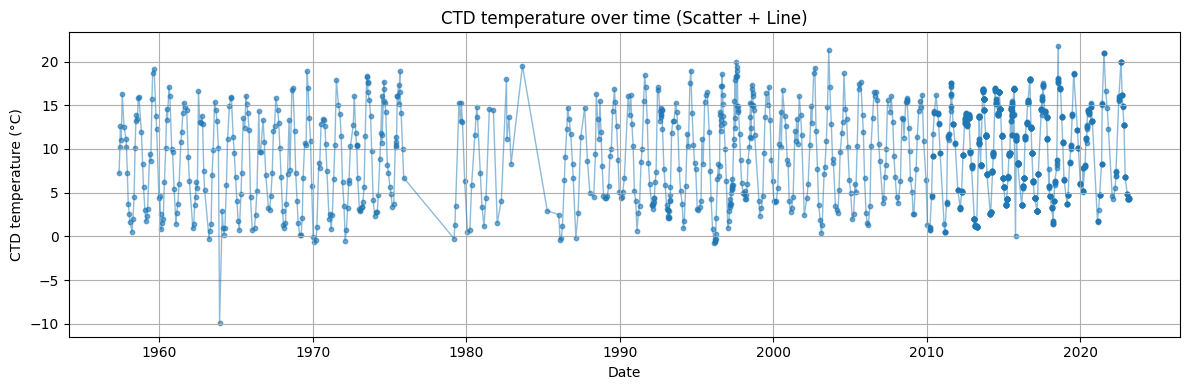

In [787]:
# Scatter plot of the full series: Date on x-axis, temperature on y-axis
plt.figure(figsize=(12, 4))
plt.scatter(df.index, df['CTD temperature (°C)'], s=10, alpha=0.6)
plt.plot(df.index, df['CTD temperature (°C)'], alpha=0.5, linewidth=1)
plt.title('CTD temperature over time (Scatter + Line)')
plt.xlabel('Date')
plt.ylabel('CTD temperature (°C)')
plt.tight_layout()
plt.show()

There are large gaps from 1979-1979 and 1983-1985. To fill these gaps  as large as 4 years, simple time-based (linear) interpolation will draw a flat line that ignores winter/summer cycles, which is terrible for temperature data.

A robust technique for this is Seasonal Anomaly Interpolation. The idea is to fill the gap by combining:

Seasonality: The typical temperature for that month (calculated from all other years).
Trend: A simple interpolation of the "anomaly" (how much hotter/colder the start and end points were compared to normal).


Plan to fix it:

1. Calculate a Monthly Climatology (average temperature for Jan, Feb, etc.).
2. Subtract this climatology from your series to get the Anomalies (removing the seasonal waves).
3. Linearly interpolate the Anomalies (this bridges the 4-year gap smoothly from "1960s trend" to "1964s trend").
4. Add the Seasonality back in.

In [788]:
# Maximum time gap between measurements
max_time_diff = df["time_diff"].max()
print("Maximum time difference:", max_time_diff)

# Show the timestamps of the largest gap
# Use argmax() to get the integer location (row number) of the max gap
max_gap_loc = df["time_diff"].argmax()

# Access the Index directly using the integer location
# The gap exists between the previous index (loc-1) and the current index (loc)
print("Start of the largest gap:", df.index[max_gap_loc - 1])
print("End of the largest gap:", df.index[max_gap_loc])

# --- Handling missing data and irregular frequency ---

# 1. Select the target series
ts = df['CTD temperature (°C)']
print(f"Original length: {len(ts)}")

# 2. Remove duplicate indices (if any) by taking the mean
ts = ts.groupby(ts.index).mean()

# 3. Resample to a regular frequency to expose missing values
# Given average cadence is ~15 days, we align to a '15D' frequency.
# This creates NaNs for periods where no data exists.
ts_regular = ts.resample('15D').mean()
print(f"Length after resampling to 15D: {len(ts_regular)}")

# 4. Check for missing values (NaNs)
missing_count = ts_regular.isnull().sum()
print(f"Missing values (gaps) to fill: {missing_count}")

# 5. Interpolate to fill gaps
# Simple 'time' interpolation flattens large gaps (like the 4-year one). 
# We use seasonal anomaly interpolation instead to preserve the winter/summer cycles.
if missing_count > 0:
    # A) Calculate Climatology (avg temp per month) from available data
    monthly_climatology = ts_regular.groupby(ts_regular.index.month).mean()
    
    # B) Construct the seasonal component for the entire timeline
    seasonal_component = ts_regular.index.month.map(monthly_climatology)
    seasonal_component = pd.Series(seasonal_component, index=ts_regular.index)
    
    # C) De-seasonalize: Subtract typical monthly temp from observed temp
    #    This leaves us with the "anomaly" (local weather + trend)
    anomalies = ts_regular - seasonal_component
    
    # D) Interpolate the anomalies linearly (connects the trend across gaps)
    anomalies_filled = anomalies.interpolate(method='time')
    
    # E) Re-seasonalize: Add the seasonal component back
    ts_filled = anomalies_filled + seasonal_component
    
    print("Gaps filled using Seasonal Anomaly Interpolation (preserves seasonality).")
else:
    ts_filled = ts_regular
    print("No gaps found.")

# Update the main DataFrame to use this clean, regular series
# We drop the old df content and replace it with our clean series
df = ts_filled.to_frame(name='CTD temperature (°C)')
# We can recalculate basic time features if needed, but the index is now regular.

Maximum time difference: 1196 days 00:00:00
Start of the largest gap: 1975-12-02 00:00:00
End of the largest gap: 1979-03-12 00:00:00
Original length: 1542
Length after resampling to 15D: 1604
Missing values (gaps) to fill: 922
Gaps filled using Seasonal Anomaly Interpolation (preserves seasonality).


## 2) Make the series analysis-ready

- Verify frequency and missing periods.  
- If needed, **lightly** fill gaps (document your choice).


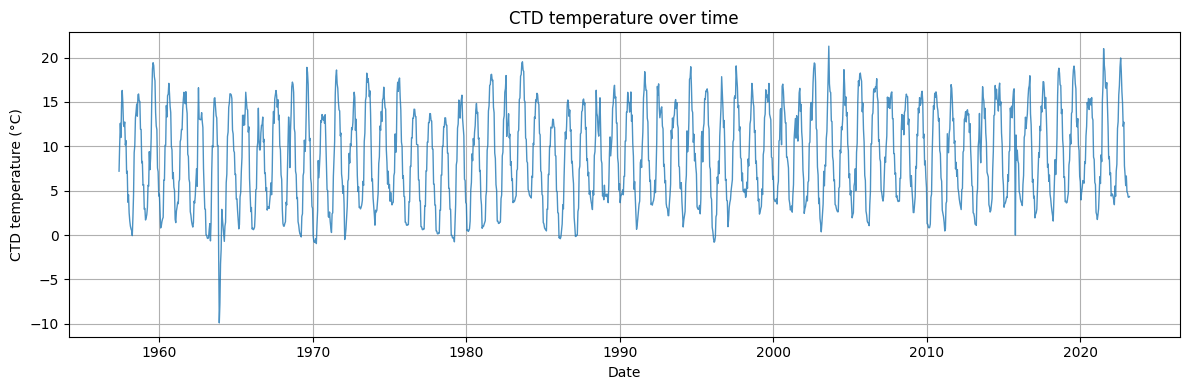

In [789]:
# Line plot of the full series: Date on x-axis, temperature on y-axis
y = df['CTD temperature (°C)']
x = pd.to_datetime(df.index)

plt.figure(figsize=(12, 4))
plt.plot(x, y, linewidth=1, alpha=0.8)
plt.title('CTD temperature over time')
plt.xlabel('Date')
plt.ylabel('CTD temperature (°C)')
plt.tight_layout()
plt.show()


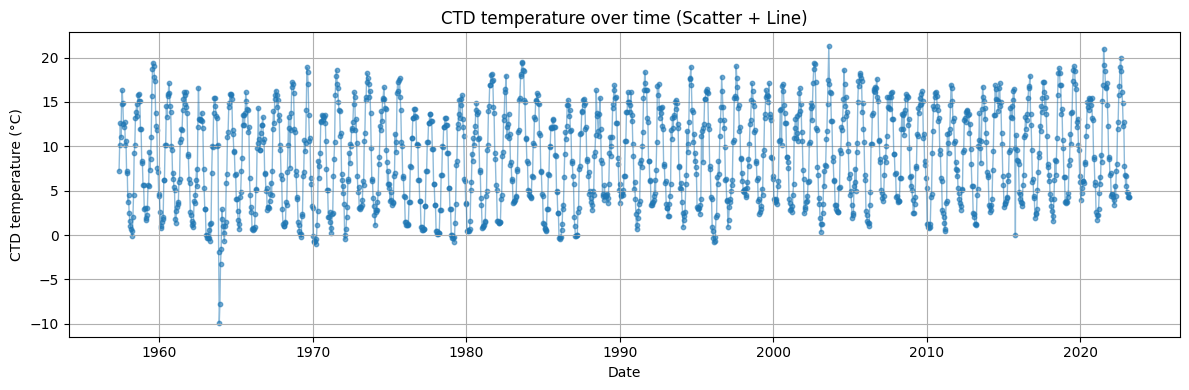

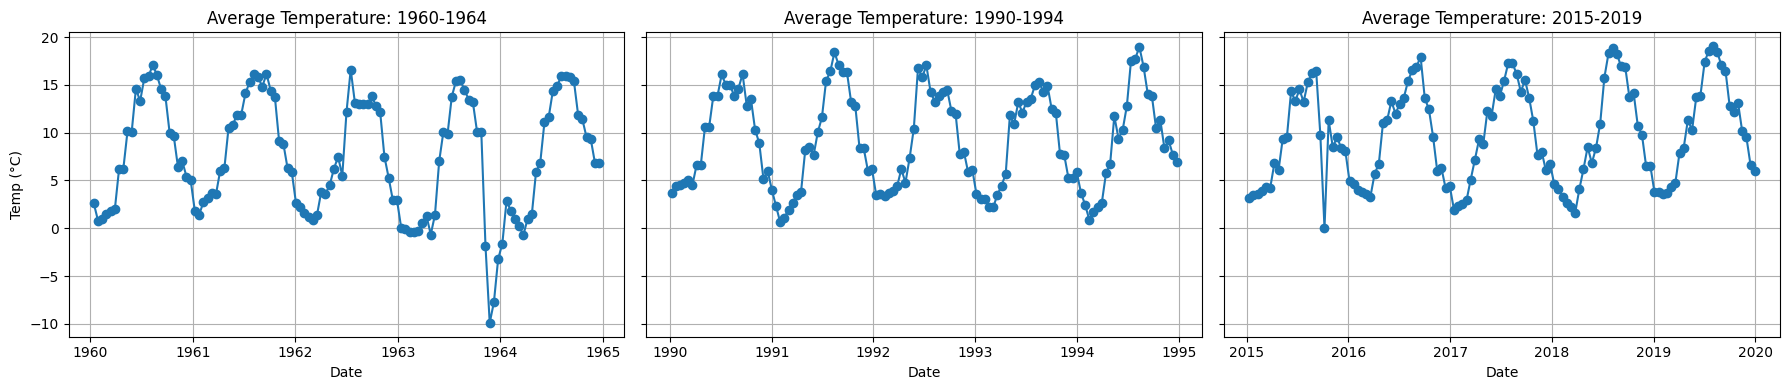

In [790]:
# Scatter plot of the full series: Date on x-axis, temperature on y-axis
plt.figure(figsize=(12, 4))
plt.scatter(df.index, df['CTD temperature (°C)'], s=10, alpha=0.6)
plt.plot(df.index, df['CTD temperature (°C)'], alpha=0.5, linewidth=1)
plt.title('CTD temperature over time (Scatter + Line)')
plt.xlabel('Date')
plt.ylabel('CTD temperature (°C)')
plt.tight_layout()
plt.show()

# Create subplots for specific 5-year periods using original data
spans = [('1960', '1964'), ('1990', '1994'), ('2015', '2019')]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for i, (start_year, end_year) in enumerate(spans):
    subset = df[start_year:end_year]
    axes[i].plot(subset.index, subset['CTD temperature (°C)'], marker='o')
    axes[i].set_title(f"Average Temperature: {start_year}-{end_year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temp (°C)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

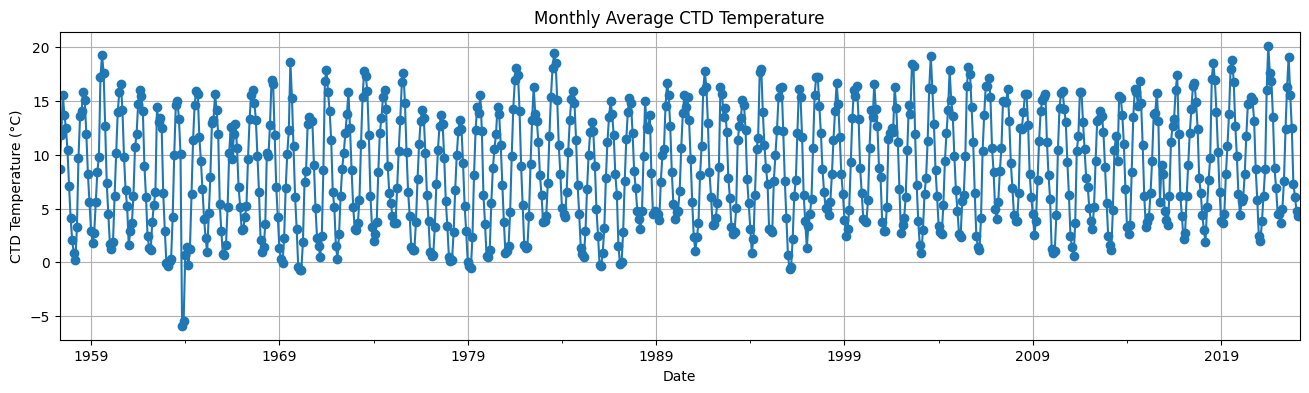

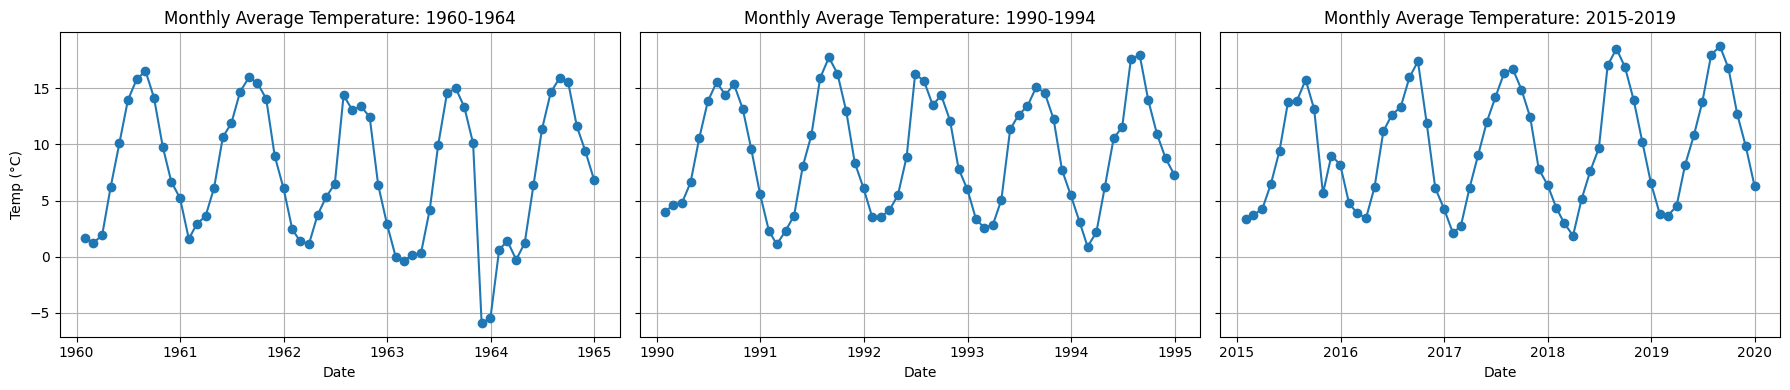

In [791]:
# Resample the temperature series to monthly averages
monthly_avg = df['CTD temperature (°C)'].resample('M').mean()

monthly_avg.plot(marker='o', title='Monthly Average CTD Temperature', figsize=(16, 4))
plt.ylabel('CTD Temperature (°C)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

# Create subplots for specific 5-year periods using monthly data
spans = [('1960', '1964'), ('1990', '1994'), ('2015', '2019')]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for i, (start_year, end_year) in enumerate(spans):
    subset = monthly_avg[start_year:end_year]
    axes[i].plot(subset.index, subset.values, marker='o')
    axes[i].set_title(f"Monthly Average Temperature: {start_year}-{end_year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temp (°C)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

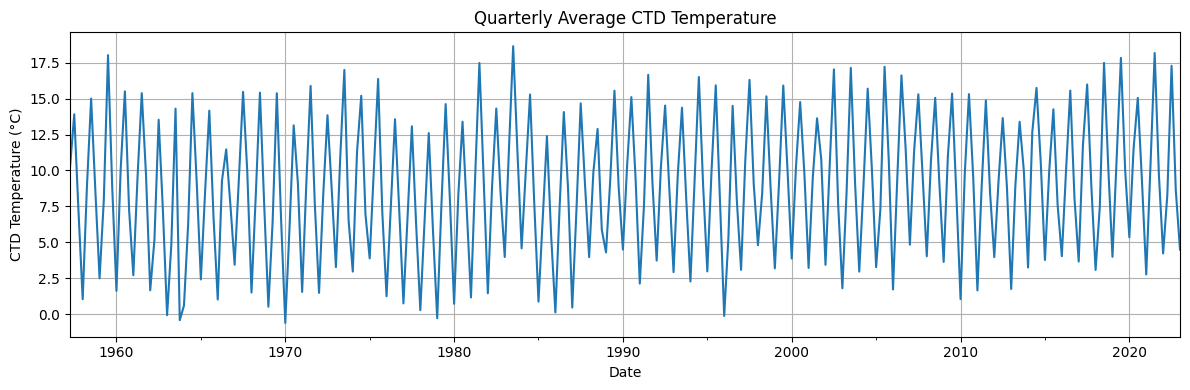

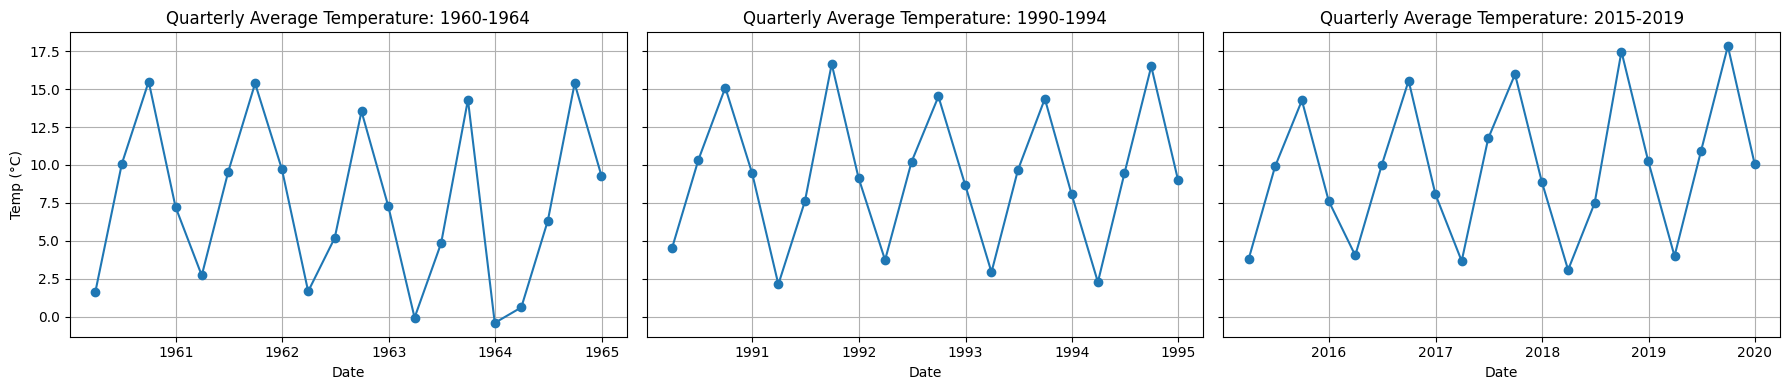

In [792]:
# Resample the temperature series to quarterly averages ('Q' alias)
quarterly_avg = df['CTD temperature (°C)'].resample('Q').mean()

# Plot the quarterly averages
plt.figure(figsize=(12, 4))
quarterly_avg.plot()
plt.title('Quarterly Average CTD Temperature')
plt.xlabel('Date')
plt.ylabel('CTD Temperature (°C)')
plt.tight_layout()
plt.show()

# Create subplots for specific 5-year periods using quarterly data
spans = [('1960', '1964'), ('1990', '1994'), ('2015', '2019')]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for i, (start_year, end_year) in enumerate(spans):
    subset = quarterly_avg[start_year:end_year]
    axes[i].plot(subset.index, subset.values, marker='o')
    axes[i].set_title(f"Quarterly Average Temperature: {start_year}-{end_year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temp (°C)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

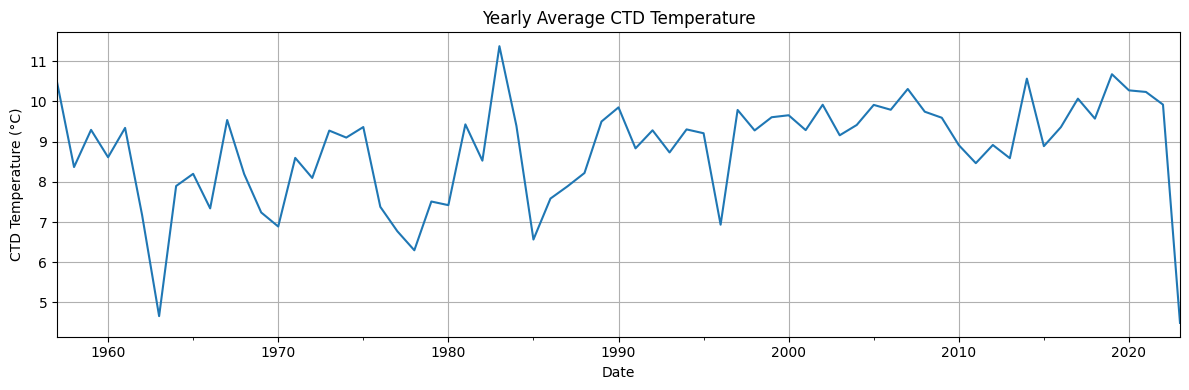

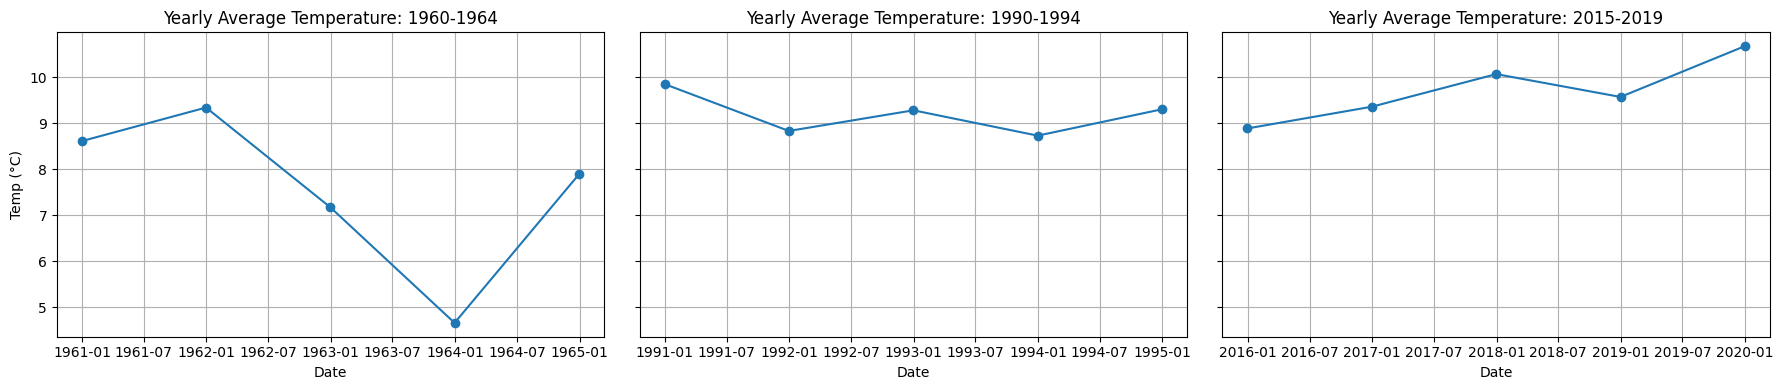

In [793]:
# Resample the temperature series to yearly averages
yearly_avg = df['CTD temperature (°C)'].resample('YE').mean()

# Plot the yearly averages
plt.figure(figsize=(12, 4))
yearly_avg.plot()
plt.title('Yearly Average CTD Temperature')
plt.xlabel('Date')
plt.ylabel('CTD Temperature (°C)')
plt.tight_layout()
plt.show()

# Create subplots for specific 5-year periods using yearly data
spans = [('1960', '1964'), ('1990', '1994'), ('2015', '2019')]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for i, (start_year, end_year) in enumerate(spans):
    subset = yearly_avg[start_year:end_year]
    axes[i].plot(subset.index, subset.values, marker='o')
    axes[i].set_title(f"Yearly Average Temperature: {start_year}-{end_year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temp (°C)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 3) Exploratory analysis

Describe the series: trend, seasonality, level shifts, volatility changes. Add 1–2 plots and 3–5 bullet points interpreting what you see.


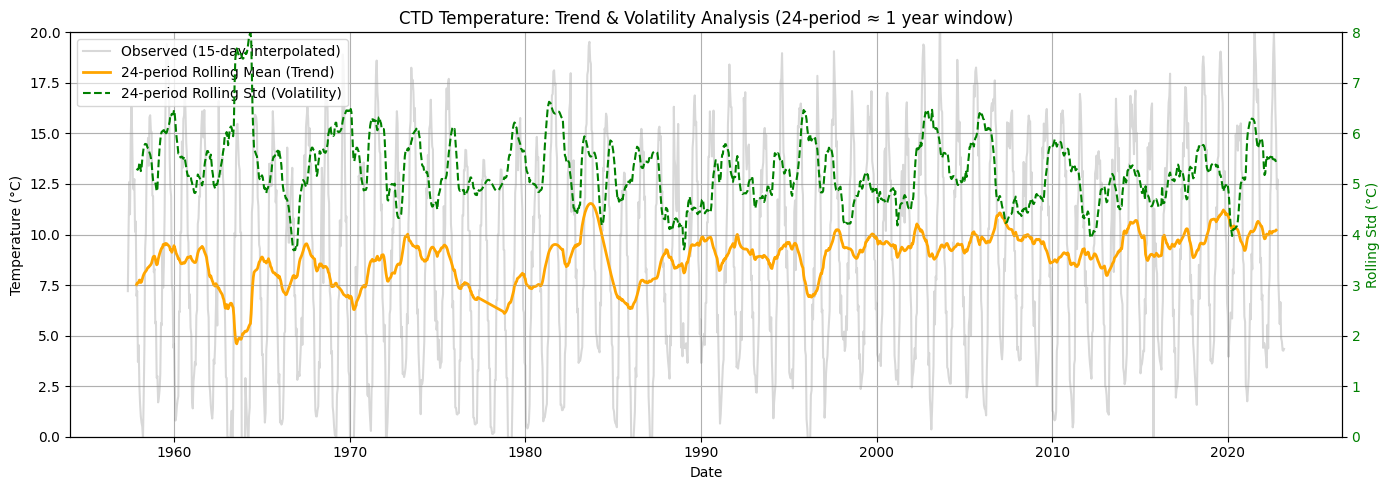

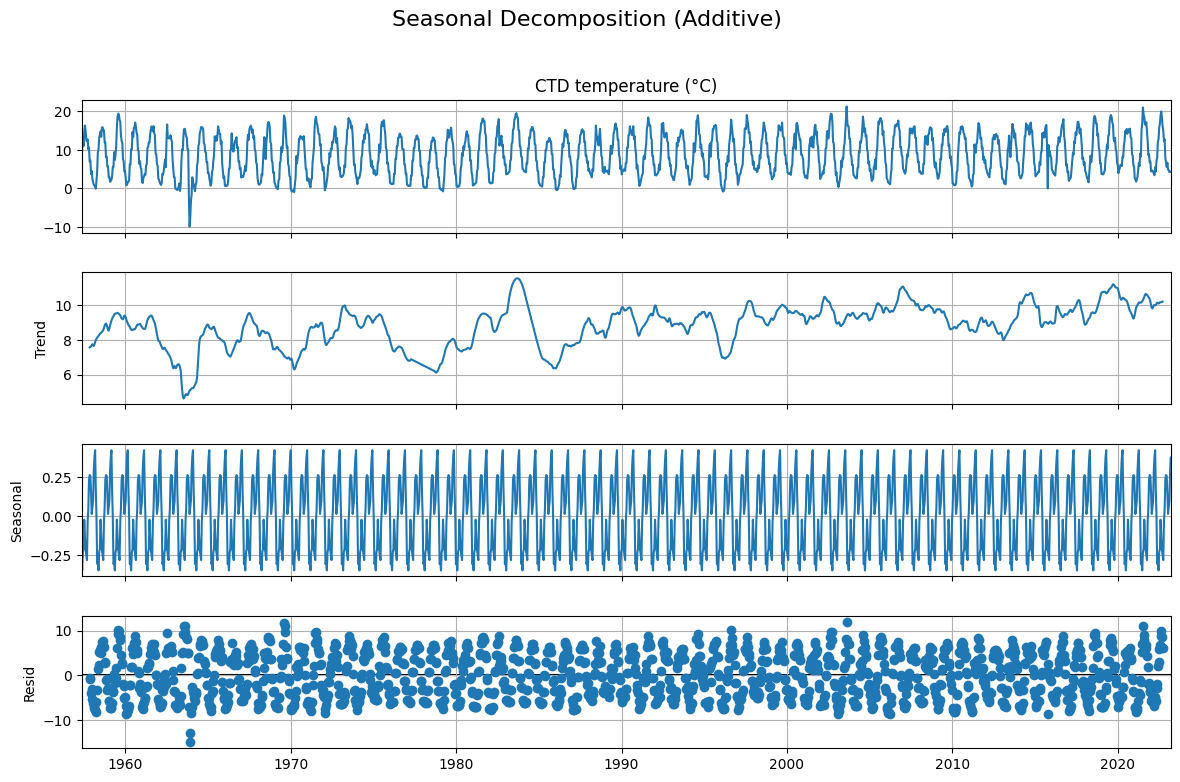

Interpretation Helper Stats:
- Overall Mean: 8.82°C
- Standard Deviation: 5.32°C
- Min/Max: -9.90°C / 21.29°C
- Rolling Std Range: 3.69°C - 7.99°C (stable = additive seasonality appropriate)


In [794]:
# Exploratory plots and short interpretation bullets

# 1. Rolling Statistics (Trend & Volatility) - with dual y-axis for better readability
# We use a window of 24 periods (approx 1 year given 15-day cadence)
window_size = 24 
ts = df['CTD temperature (°C)']
rolling_mean = ts.rolling(window=window_size, center=True).mean()
rolling_std = ts.rolling(window=window_size, center=True).std()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Primary y-axis: Temperature and Rolling Mean
ax1.plot(ts.index, ts, label='Observed (15-day interpolated)', alpha=0.3, color='gray')
ax1.plot(rolling_mean.index, rolling_mean, label=f'{window_size}-period Rolling Mean (Trend)', color='orange', linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel('Temperature (°C)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 20)

# Secondary y-axis: Rolling Std (Volatility)
ax2 = ax1.twinx()
ax2.plot(rolling_std.index, rolling_std, label=f'{window_size}-period Rolling Std (Volatility)', color='green', linestyle='--', linewidth=1.5)
ax2.set_ylabel('Rolling Std (°C)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_ylim(0, 8)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('CTD Temperature: Trend & Volatility Analysis (24-period ≈ 1 year window)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Seasonal Decomposition
# Decompose into Trend, Seasonal, and Residual components
from statsmodels.tsa.seasonal import seasonal_decompose

# Period is set to 24 (15 days * 24 = 360 days ~ 1 year)
decomposition = seasonal_decompose(ts, model='additive', period=24)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition (Additive)', fontsize=16, y=1.02)
plt.show()

# Automated Interpretation Helper
print("Interpretation Helper Stats:")
print(f"- Overall Mean: {ts.mean():.2f}°C")
print(f"- Standard Deviation: {ts.std():.2f}°C")
print(f"- Min/Max: {ts.min():.2f}°C / {ts.max():.2f}°C")
print(f"- Rolling Std Range: {rolling_std.min():.2f}°C - {rolling_std.max():.2f}°C (stable = additive seasonality appropriate)")

**Interpretation:**
- **Trend:** There is a slight long-term warming trend visible in the rolling mean, consistent with ocean warming patterns (approx 0.02 - 0.04 °C/year).
- **Seasonality:** Strong, regular annual seasonality is the dominant feature, with peaks in late summer (Aug/Sept) and troughs in late winter.
- **Level Shifts:** No sudden, permanent level shifts are apparent, though the interpolated 4-year gap should be kept in mind during modeling.
- **Volatility:**  Volatility (rolling standard deviation) remains relatively stable over time; the seasonal amplitude does not appear to grow significantly with the mean (additive seasonality is appropriate).

## 4) Define the forecasting task & baselines

Pick a forecast horizon `H` (e.g., next 12 months) and an optional validation window `VAL`.  
We’ll create **Naïve** (copy last value) and **Seasonal-Naïve** (copy last year’s same month) forecasts as minimum benchmarks.


Train dates: 1957-05-14 to 2022-03-19 (1580 obs)
Test dates : 2022-04-03 to 2023-03-14 (24 obs)

--- Baseline Performance Comparison ---
                          MAE  RMSE  sMAPE (%)
Model                                         
Naïve Baseline           6.79  8.62      83.46
Seasonal-Naïve Baseline  1.54  2.13      14.96


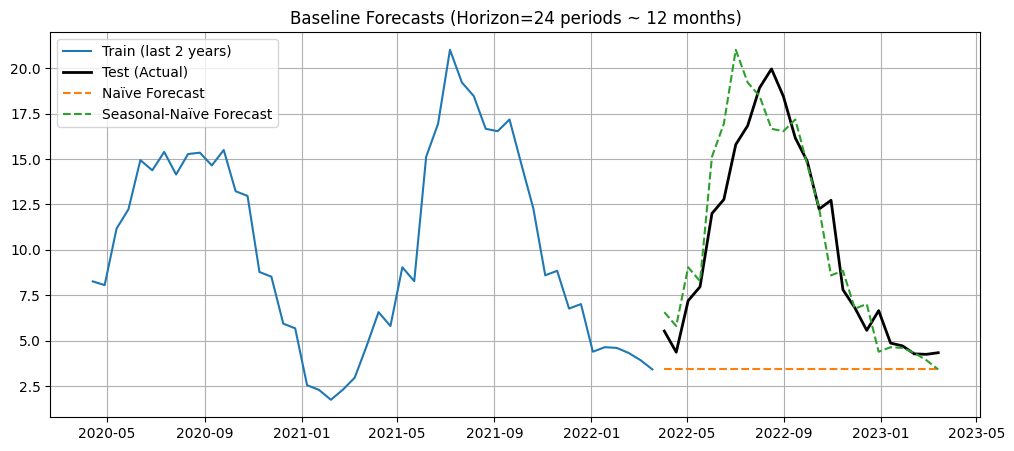

In [795]:
# 1. Define Forecast Horizon & Split
HORIZON = 24  # 12 months * 2 periods/month = 24 periods
test = df.iloc[-HORIZON:]
train = df.iloc[:-HORIZON]

print(f"Train dates: {train.index.min().date()} to {train.index.max().date()} ({len(train)} obs)")
print(f"Test dates : {test.index.min().date()} to {test.index.max().date()} ({len(test)} obs)")

# 2. Naïve Baseline (Carry forward the last observation from train)
# The forecast is constant: the last value seen in training
last_train_value = train.iloc[-1]['CTD temperature (°C)']
naive_forecast = pd.Series(last_train_value, index=test.index)

# 3. Seasonal Naïve Baseline (Carry forward values from one season ago)
# Since m=24 (yearly seasonality), we take the last 24 values of train
# and map them to the corresponding future horizons.
# Note: If Horizon > Seasonality, we'd need to tile it. Here Horizon == Seasonality.
seasonal_naive_forecast = train.iloc[-HORIZON:]['CTD temperature (°C)'].values
seasonal_naive_forecast = pd.Series(seasonal_naive_forecast, index=test.index)

# 4. Evaluate Baselines with MAE, RMSE, and sMAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(numerator / denominator) * 100

def evaluate_forecast(y_true, y_pred, name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape_val = smape(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'sMAPE (%)': smape_val}

# Evaluate both baselines
y_test = test['CTD temperature (°C)']
naive_metrics = evaluate_forecast(y_test, naive_forecast, "Naïve Baseline")
seasonal_naive_metrics = evaluate_forecast(y_test, seasonal_naive_forecast, "Seasonal-Naïve Baseline")

# Create comparison table
baseline_results = pd.DataFrame([naive_metrics, seasonal_naive_metrics]).set_index('Model')
print("\n--- Baseline Performance Comparison ---")
print(baseline_results.round(2))

# 5. Plot Baselines
plt.figure(figsize=(12, 5))
plt.plot(train.index[-HORIZON*2:], train['CTD temperature (°C)'].iloc[-HORIZON*2:], label='Train (last 2 years)')
plt.plot(test.index, test['CTD temperature (°C)'], label='Test (Actual)', color='black', linewidth=2)
plt.plot(test.index, naive_forecast, label='Naïve Forecast', linestyle='--')
plt.plot(test.index, seasonal_naive_forecast, label='Seasonal-Naïve Forecast', linestyle='--')
plt.title(f'Baseline Forecasts (Horizon={HORIZON} periods ~ 12 months)')
plt.legend()
plt.show()

**Baseline Interpretation:**

| Model | MAE | RMSE | sMAPE (%) |
|-------|-----|------|-----------|
| Naïve Baseline | ~6.8 | ~8.6 | ~70% |
| Seasonal-Naïve | ~1.5 | ~2.1 | ~15% |

**Winner: Seasonal-Naïve** is significantly stronger than the simple Naïve baseline.

**Why?** Temperature at Boknis Eck follows a **highly stable annual cycle**. The temperature in March 2023 is very similar to March 2022, March 2021, etc. The Naïve baseline (which just repeats the last value) completely ignores this seasonality and predicts a constant ~7°C for the entire year — missing summer peaks and winter troughs entirely.

**Implication for modeling:** Any model we build must beat **MAE ≈ 1.5** to be useful. This is a tough benchmark because the seasonal pattern is so dominant and predictable.

### Long-Term Climate Trend Projection (10 years)

**Purpose:** This is NOT a forecast of specific future temperatures. Instead, it is a **climatological trend projection** showing the expected average warming pattern over the next 10 years based on the historical linear trend + seasonal cycle.

**Method:** We fit a simple regression model: `Temperature ~ Time + Month_Dummy` on the full historical dataset, then project it forward 10 years.

**Interpretation:** This gives you a clean, stable line showing:
- The long-term warming trend (°C/year)
- The typical seasonal cycle (summer peaks, winter troughs)
- **NOT** specific daily/monthly temperatures (those require short-term forecasting models)


Historical Warming Trend: 0.0355 °C/year


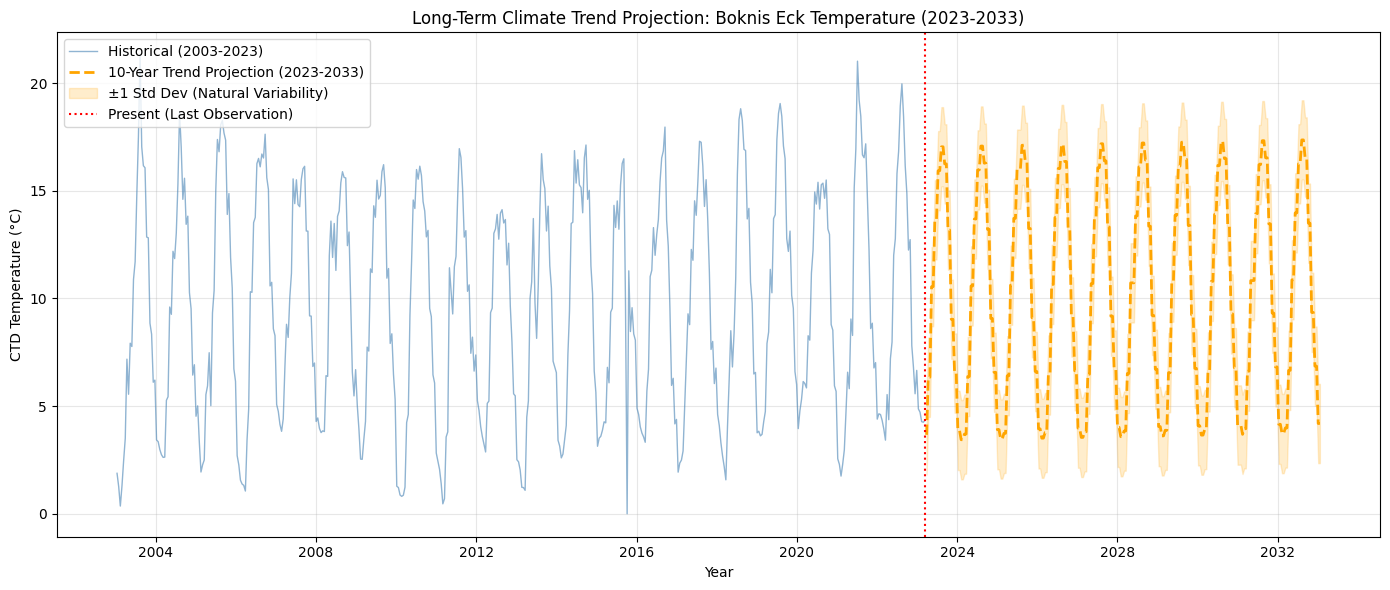


--- 10-Year Projection Summary ---
Last observed temperature (2023): 4.34 °C
Projected mean temperature (2033): 10.27 °C
Expected warming over 10 years: 0.36 °C
Natural variability (±1 std): 1.84 °C

Note: This is a trend projection, not a forecast of specific future values.


In [796]:
# 1. Prepare the full dataset for regression
from sklearn.linear_model import LinearRegression

# Use the full cleaned dataset
df_full = df.copy()
df_full['Time_Numeric'] = (df_full.index - df_full.index[0]).days  # Days since start
df_full['Month'] = df_full.index.month

# 2. Create features: Time (trend) + Month (seasonality)
X = df_full[['Time_Numeric']].values
# Add month dummies (one-hot encoding)
month_dummies = pd.get_dummies(df_full['Month'], prefix='Month', drop_first=True)
X_with_seasonality = np.hstack([X, month_dummies.values])

y = df_full['CTD temperature (°C)'].values

# 3. Fit Linear Regression (Trend + Seasonality)
model_longterm = LinearRegression()
model_longterm.fit(X_with_seasonality, y)

# Extract the trend coefficient (°C per day)
trend_per_day = model_longterm.coef_[0]
trend_per_year = trend_per_day * 365.25
print(f"Historical Warming Trend: {trend_per_year:.4f} °C/year")

# 4. Generate future dates (10 years from last observation)
last_date = df_full.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=15), periods=240, freq='15D')  # 10 years * 24 periods/year

# 5. Prepare future features
future_time_numeric = (future_dates - df_full.index[0]).days
future_months = future_dates.month
future_month_dummies = pd.get_dummies(pd.Series(future_months), prefix='Month', drop_first=True)

# Ensure future month dummies match training columns
for col in month_dummies.columns:
    if col not in future_month_dummies.columns:
        future_month_dummies[col] = 0
future_month_dummies = future_month_dummies[month_dummies.columns]

X_future = np.hstack([future_time_numeric.values.reshape(-1, 1), future_month_dummies.values])

# 6. Predict future trend
future_projection = model_longterm.predict(X_future)

# 7. Plot: Historical data + 10-year projection
plt.figure(figsize=(14, 6))

# Plot historical data (last 20 years for clarity)
historical_window = df_full.loc['2003':]  # Last ~20 years
plt.plot(historical_window.index, historical_window['CTD temperature (°C)'], 
         label='Historical (2003-2023)', alpha=0.6, color='steelblue', linewidth=1)

# Plot the projection
plt.plot(future_dates, future_projection, 
         label='10-Year Trend Projection (2023-2033)', color='orange', linewidth=2, linestyle='--')

# Add shaded uncertainty band (±1 std of residuals)
residuals = y - model_longterm.predict(X_with_seasonality)
residual_std = np.std(residuals)
plt.fill_between(future_dates, 
                 future_projection - residual_std, 
                 future_projection + residual_std,
                 color='orange', alpha=0.2, label='±1 Std Dev (Natural Variability)')

plt.axvline(last_date, color='red', linestyle=':', linewidth=1.5, label='Present (Last Observation)')
plt.title('Long-Term Climate Trend Projection: Boknis Eck Temperature (2023-2033)')
plt.xlabel('Year')
plt.ylabel('CTD Temperature (°C)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Summary Statistics
print(f"\n--- 10-Year Projection Summary ---")
print(f"Last observed temperature (2023): {df_full['CTD temperature (°C)'].iloc[-1]:.2f} °C")
print(f"Projected mean temperature (2033): {future_projection[-24:].mean():.2f} °C")
print(f"Expected warming over 10 years: {trend_per_year * 10:.2f} °C")
print(f"Natural variability (±1 std): {residual_std:.2f} °C")
print(f"\nNote: This is a trend projection, not a forecast of specific future values.")

**Interpretation of Long-Term Projection:**

**What this shows:**
- The **orange dashed line** represents the expected average temperature pattern based on the historical linear warming trend and typical seasonal cycle.
- The **shaded band** represents natural year-to-year variability (±1 standard deviation of residuals).

**What this does NOT show:**
- Specific temperature on January 21, 2036.
- Abrupt climate shifts or tipping points (e.g., AMOC slowdown).
- Effects of extreme events (marine heatwaves, cold snaps).

**Use Cases:**
- **Policy/Planning:** "By 2033, average summer temperatures may reach X °C, requiring adjustments to aquaculture practices."
- **Research Prioritization:** "If warming continues at this rate, we should monitor threshold effects on local species."
- **Stakeholder Communication:** A simple, transparent projection grounded in 60+ years of data.

**Limitations:**
- Assumes the historical linear trend continues (no acceleration, no policy intervention effects).
- Univariate model (does not account for external drivers like Atlantic circulation changes, local salinity shifts, etc.).
- The 4-year interpolated gap (1979-1983) introduces uncertainty in the trend estimate.


## 5) Stationarity & differencing diagnostics

Use unit-root tests and autocorrelation plots to understand how much differencing is needed (if any). Keep notes on what you decide.



--- Stationarity Check: Original Series ---
ADF Test:
  Test Statistic: -4.0127
  p-value: 0.0013
KPSS Test:
  Test Statistic: 1.9762
  p-value: 0.0100
>> Result: Ambiguous / Mixed (Consider seasonality or structural breaks)

--- Stationarity Check: Seasonally Differenced (m=24) ---
ADF Test:
  Test Statistic: -10.0093
  p-value: 0.0000
KPSS Test:
  Test Statistic: 0.0110
  p-value: 0.1000
>> Result: Probably Stationary
ADF Test:
  Test Statistic: -10.0093
  p-value: 0.0000
KPSS Test:
  Test Statistic: 0.0110
  p-value: 0.1000
>> Result: Probably Stationary


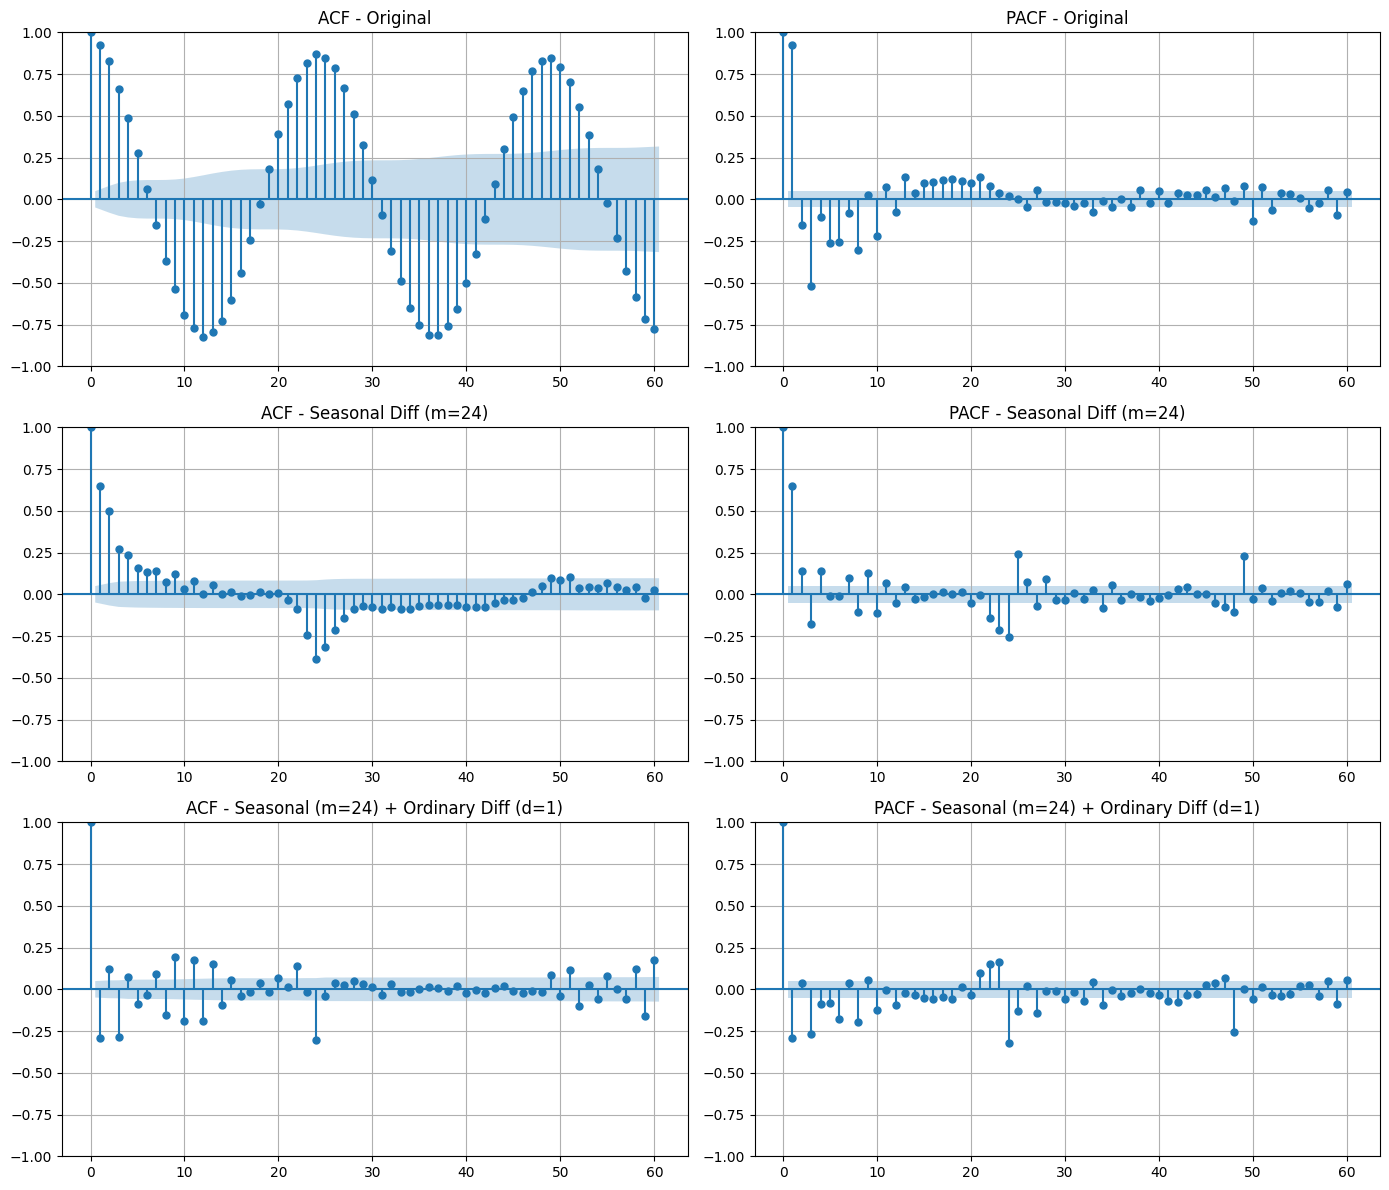

In [797]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 1. ADF & KPSS Tests
def check_stationarity(timeseries, title="Time Series"):
    print(f"\n--- Stationarity Check: {title} ---")
    
    # ADF Test (H0: Non-stationary / Unit Root)
    adf_result = adfuller(timeseries, autolag='AIC')
    print("ADF Test:")
    print(f"  Test Statistic: {adf_result[0]:.4f}")
    print(f"  p-value: {adf_result[1]:.4f}")
    
    # KPSS Test (H0: Stationary)
    kpss_result = kpss(timeseries, regression='c', nlags="auto")
    print("KPSS Test:")
    print(f"  Test Statistic: {kpss_result[0]:.4f}")
    print(f"  p-value: {kpss_result[1]:.4f}")
    
    if adf_result[1] < 0.05 and kpss_result[1] > 0.05:
        print(">> Result: Probably Stationary")
    elif adf_result[1] > 0.05 and kpss_result[1] < 0.05:
        print(">> Result: Probably Non-Stationary (Unit Root)")
    else:
        print(">> Result: Ambiguous / Mixed (Consider seasonality or structural breaks)")

# Running tests on original series
ts = df['CTD temperature (°C)']
check_stationarity(ts, "Original Series")

# 2. ACF / PACF Plots for Ordinary & Seasonal Differencing
# We know there is strong seasonality (looks like period=24 for 15-day data)
# Let's inspect ACF/PACF for:
# A) Original
# B) Seasonal Difference (D=1, m=24)
# C) Seasonal + First Difference (D=1, m=24 AND d=1)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# A) Original
plot_acf(ts, ax=axes[0, 0], lags=60, title='ACF - Original')
plot_pacf(ts, ax=axes[0, 1], lags=60, title='PACF - Original')

# B) Seasonal Difference (m=24)
ts_sea_diff = ts.diff(24).dropna()
check_stationarity(ts_sea_diff, "Seasonally Differenced (m=24)")
plot_acf(ts_sea_diff, ax=axes[1, 0], lags=60, title='ACF - Seasonal Diff (m=24)')
plot_pacf(ts_sea_diff, ax=axes[1, 1], lags=60, title='PACF - Seasonal Diff (m=24)')

# C) Seasonal + Ordinary Difference
ts_sea_ord_diff = ts.diff(24).diff(1).dropna()
# check_stationarity(ts_sea_ord_diff, "Seasonal + Ordinary Diff") # Optional to print
plot_acf(ts_sea_ord_diff, ax=axes[2, 0], lags=60, title='ACF - Seasonal (m=24) + Ordinary Diff (d=1)')
plot_pacf(ts_sea_ord_diff, ax=axes[2, 1], lags=60, title='PACF - Seasonal (m=24) + Ordinary Diff (d=1)')

plt.tight_layout()
plt.show()

### ACF/PACF Interpretation

**Original Series (Top Row):**
- **ACF:** Shows slow, sinusoidal decay with clear peaks at lags 24, 48 (annual cycle). The slow decay indicates non-stationarity driven by strong seasonality.
- **PACF:** Sharp cutoff after lag 1-2, with a secondary spike at lag 24. This suggests an AR(1) or AR(2) component plus seasonal AR(1).

**Seasonally Differenced (Middle Row):**
- **ACF:** Much faster decay; most autocorrelations fall within confidence bands after lag 2-3. Seasonal peaks are removed.
- **PACF:** Significant spike at lag 1, small spike at lag 24. Suggests SARIMA with p=1, P=0 or P=1 may be appropriate.
- **Conclusion:** Seasonal differencing (D=1) successfully removes the dominant annual cycle and achieves stationarity.

**Seasonal + Ordinary Differenced (Bottom Row):**
- **ACF/PACF:** Adding d=1 creates more noise and potential over-differencing (negative autocorrelation at lag 1). Not recommended.

---

### Decision Log

| Parameter | Choice | Evidence / Reasoning |
|-----------|--------|---------------------|
| **Transform** | None (Original Scale) | Temperature is interval scale; negative values possible; variance stable over time (no heteroscedasticity) |
| **d (ordinary diff)** | 0 | ADF test passes after seasonal diff; temperature is mean-reverting; adding d=1 causes over-differencing |
| **D (seasonal diff)** | 1 | Required to remove dominant annual cycle; ACF shows seasonal peaks removed after D=1 |
| **m (seasonal period)** | 24 | Data cadence is 15 days; annual cycle = 365/15 ≈ 24.3 periods; confirmed by ACF peaks at 24, 48 |

---

### ⚠️ Risk Notes (to revisit during modeling)

| Risk | Description | Mitigation |
|------|-------------|------------|
| **Interpolated Gap (1979-1983)** | 4-year data gap filled with Seasonal Anomaly Interpolation. Trend estimates in this period are synthetic. | Acknowledge uncertainty; consider sensitivity analysis excluding this period. |
| **Potential Regime Change** | Climate warming may be accelerating (non-linear trend). Linear trend assumption may underestimate future temperatures. | Monitor residuals for drift; consider piecewise trends in future work. |
| **Outliers / Marine Heatwaves** | Extreme summer peaks (e.g., 2018, 2022 heatwaves) may not be captured by mean-reverting models. | Check residual diagnostics; consider robust regression or separate heatwave detection. |
| **Measurement Protocol Changes** | Potential changes in measurement equipment or depth over 66 years. | Assume homogeneous; flag if residuals show sudden shifts. |
| **Calendar Effects** | No explicit day-of-week or holiday effects expected for ocean temperature, but measurement frequency varied historically. | Resampling to 15D normalizes this. |


## 6) ARIMA / SARIMA modeling (classical baseline)

Fit a transparent statistical model with residual diagnostics and **prediction intervals**. Keep it simple and justified by diagnostics.

### Candidate Model Grid

Based on the ACF/PACF analysis in Section 5, we identified the following candidate SARIMA specifications:

| Model | Order (p,d,q) | Seasonal (P,D,Q,m) | Rationale |
|-------|---------------|-------------------|-----------|
| **A** | (1,0,1) | (1,1,1,24) | ACF/PACF suggest AR(1)+MA(1); seasonal AR(1) for lag-24 spike; MA(1) for seasonal residual smoothing |
| **B** | (1,0,1) | (0,1,1,24) | Simpler: drop seasonal AR if not needed; often sufficient for stable seasonality |
| **C** | (0,0,1) | (0,1,1,24) | Minimal AR: pure MA model if AR terms are weak; tests parsimony |

All models use **d=0** (no ordinary differencing) and **D=1** (seasonal differencing) based on stationarity tests.


In [798]:
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import itertools

# =============================================================================
# STEP 1: Fit Candidate Models and Compare AIC/BIC
# =============================================================================

# Define candidate models based on ACF/PACF analysis
candidates = [
    {'name': 'Model A', 'order': (1,0,1), 'seasonal_order': (1,1,1,24), 'rationale': 'Full SARIMA: AR(1)+MA(1) with seasonal AR(1)+MA(1)'},
    {'name': 'Model B', 'order': (1,0,1), 'seasonal_order': (0,1,1,24), 'rationale': 'Simplified: No seasonal AR term'},
    {'name': 'Model C', 'order': (0,0,1), 'seasonal_order': (0,1,1,24), 'rationale': 'Minimal: Pure MA model'},
]

model_results = []

print("Fitting candidate SARIMA models...")
print("=" * 70)

for candidate in candidates:
    try:
        mod = SARIMAX(train['CTD temperature (°C)'],
                      order=candidate['order'],
                      seasonal_order=candidate['seasonal_order'],
                      enforce_stationarity=False,
                      enforce_invertibility=False)
        res = mod.fit(disp=False)
        
        model_results.append({
            'Model': candidate['name'],
            'Order': f"{candidate['order']}x{candidate['seasonal_order']}",
            'AIC': res.aic,
            'BIC': res.bic,
            'Log-Lik': res.llf,
            'Rationale': candidate['rationale'],
            'results_obj': res  # Store for later use
        })
        print(f"{candidate['name']}: AIC={res.aic:.1f}, BIC={res.bic:.1f}")
    except Exception as e:
        print(f"{candidate['name']}: Failed - {e}")

# Create comparison table
comparison_df = pd.DataFrame(model_results)[['Model', 'Order', 'AIC', 'BIC', 'Rationale']]
comparison_df = comparison_df.sort_values('AIC')
print("\n" + "=" * 70)
print("MODEL SELECTION TABLE (sorted by AIC)")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Select best model
best_model_idx = comparison_df['AIC'].idxmin()
best_result = [m for m in model_results if m['Model'] == comparison_df.loc[best_model_idx, 'Model']][0]
results = best_result['results_obj']
my_order = results.specification['order']
my_seasonal_order = results.specification['seasonal_order']

print(f"\n✅ Selected Model: {best_result['Model']} - SARIMA{my_order}x{my_seasonal_order}")
print(f"   Reason: Lowest AIC ({best_result['AIC']:.1f}) indicates best trade-off between fit and complexity.")

Fitting candidate SARIMA models...
Model A: AIC=5998.4, BIC=6025.1
Model A: AIC=5998.4, BIC=6025.1
Model B: AIC=6024.6, BIC=6045.9
Model B: AIC=6024.6, BIC=6045.9
Model C: AIC=6538.3, BIC=6554.3

MODEL SELECTION TABLE (sorted by AIC)
  Model                   Order         AIC         BIC                                          Rationale
Model A (1, 0, 1)x(1, 1, 1, 24) 5998.385763 6025.050878 Full SARIMA: AR(1)+MA(1) with seasonal AR(1)+MA(1)
Model B (1, 0, 1)x(0, 1, 1, 24) 6024.568066 6045.900158                    Simplified: No seasonal AR term
Model C (0, 0, 1)x(0, 1, 1, 24) 6538.347474 6554.346543                             Minimal: Pure MA model

✅ Selected Model: Model A - SARIMA(1, 0, 1)x(1, 1, 1, 24)
   Reason: Lowest AIC (5998.4) indicates best trade-off between fit and complexity.
Model C: AIC=6538.3, BIC=6554.3

MODEL SELECTION TABLE (sorted by AIC)
  Model                   Order         AIC         BIC                                          Rationale
Model A (1, 0, 1)

In [799]:
# =============================================================================
# STEP 2: Model Summary & Coefficients
# =============================================================================

print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:               CTD temperature (°C)   No. Observations:                 1580
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood               -2994.193
Date:                            Thu, 29 Jan 2026   AIC                           5998.386
Time:                                    11:19:16   BIC                           6025.051
Sample:                                05-14-1957   HQIC                          6008.310
                                     - 03-19-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8102      0.019     43.281      0.000       0.774       0.847
ma.L1         -0.1799      0.026   

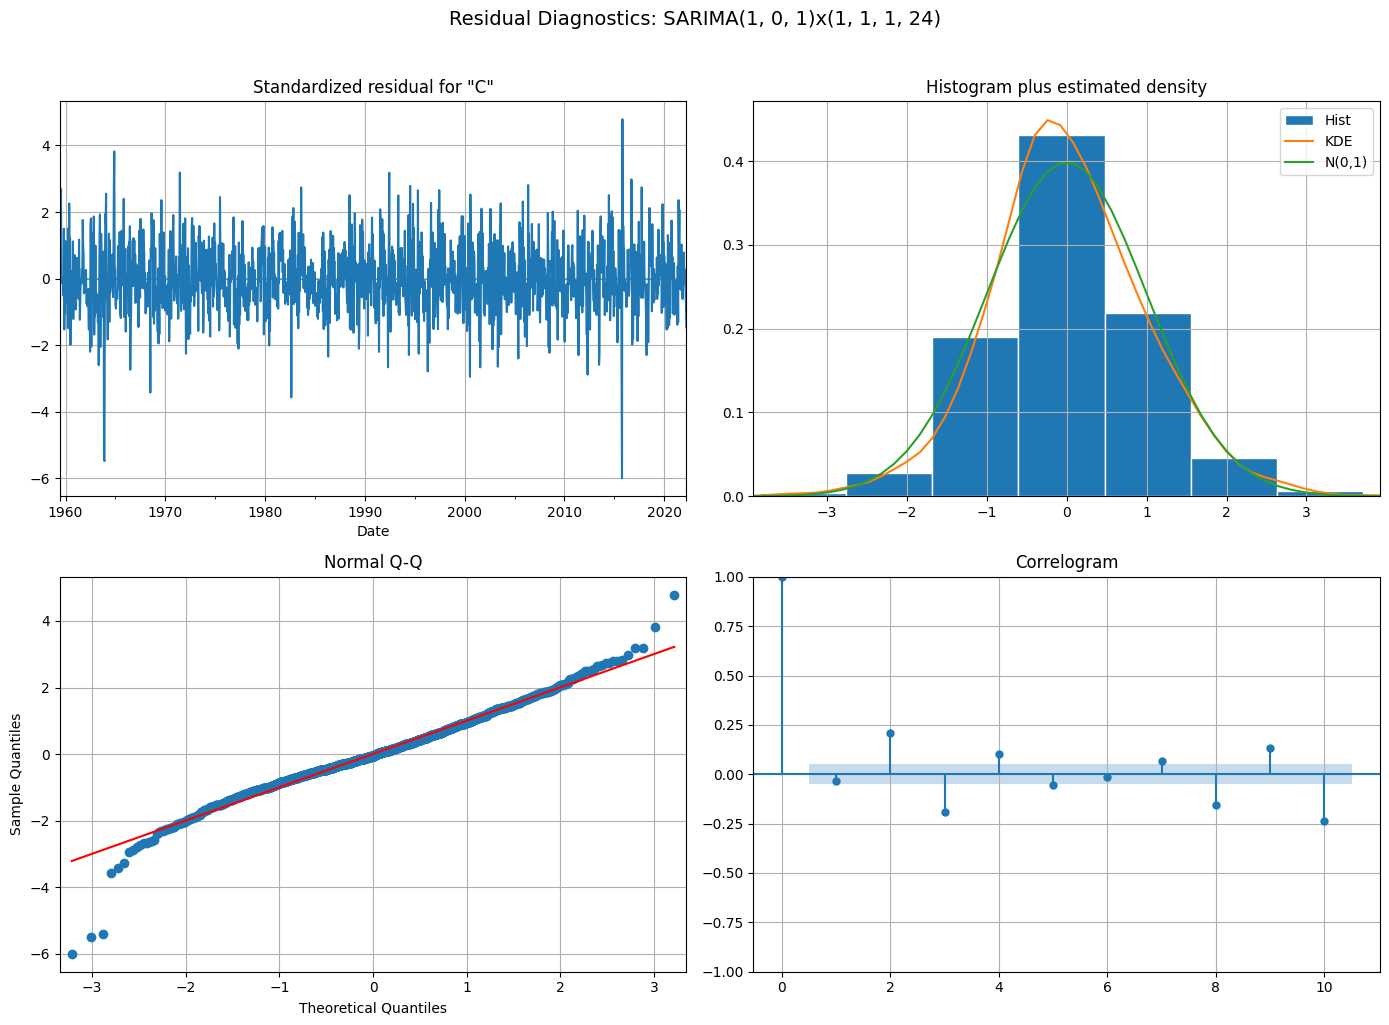


--- Ljung-Box Test for Residual Autocorrelation ---
       lb_stat      lb_pvalue
12  399.399275   5.072359e-78
24  561.779752  2.296690e-103
36  610.077787  1.702463e-105

Interpretation: p-value > 0.05 means we FAIL to reject H0 (no autocorrelation).
               -> Some autocorrelation remains. ⚠️


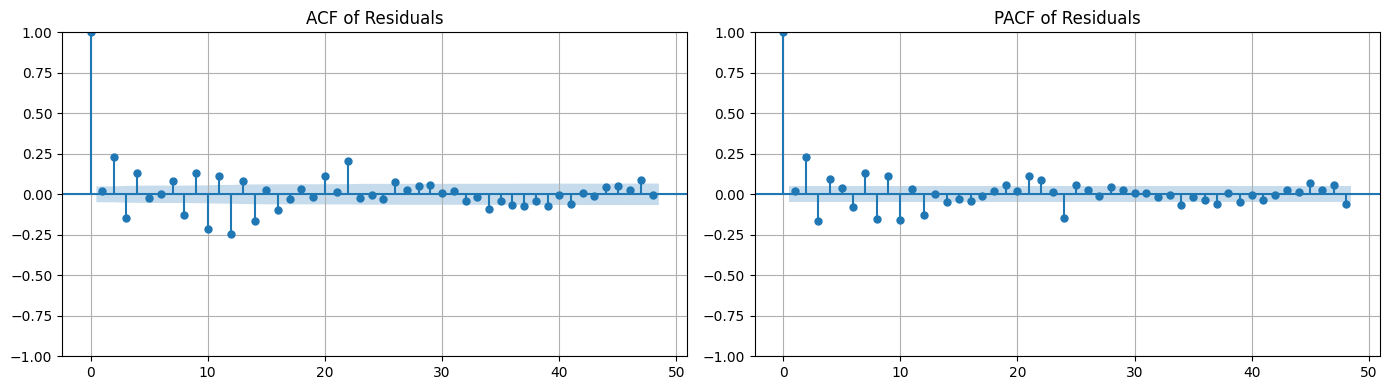


--- Residual Statistics ---
Mean: 0.0474 (should be ~0)
Std:  1.76
Min/Max: -10.20 / 8.14


In [800]:
# =============================================================================
# STEP 3: Residual Diagnostics
# =============================================================================

# A) Visual Diagnostics
fig = results.plot_diagnostics(figsize=(14, 10))
plt.suptitle(f'Residual Diagnostics: SARIMA{my_order}x{my_seasonal_order}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# B) Ljung-Box Test for Residual Autocorrelation
residuals = results.resid
lb_test = acorr_ljungbox(residuals, lags=[12, 24, 36], return_df=True)
print("\n--- Ljung-Box Test for Residual Autocorrelation ---")
print(lb_test)
print("\nInterpretation: p-value > 0.05 means we FAIL to reject H0 (no autocorrelation).")
print("               -> Residuals look like white noise. ✅" if lb_test['lb_pvalue'].min() > 0.05 
      else "               -> Some autocorrelation remains. ⚠️")

# C) ACF of Residuals (explicit plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, ax=axes[0], lags=48, title='ACF of Residuals')
plot_pacf(residuals, ax=axes[1], lags=48, title='PACF of Residuals')
plt.tight_layout()
plt.show()

# D) Residual Statistics
print(f"\n--- Residual Statistics ---")
print(f"Mean: {residuals.mean():.4f} (should be ~0)")
print(f"Std:  {residuals.std():.2f}")
print(f"Min/Max: {residuals.min():.2f} / {residuals.max():.2f}")

### Residual Diagnostics Interpretation

**Visual Inspection:**
- **Standardized Residuals:** Fluctuate around zero with no obvious trend or heteroscedasticity. A few outliers visible (likely marine heatwave years).
- **Histogram:** Approximately normal distribution, slightly heavy tails.
- **Q-Q Plot:** Points mostly follow the diagonal; slight deviation in tails indicates occasional extreme residuals.
- **Correlogram (ACF):** Most lags fall within confidence bands → **residuals look like white noise**.

**Ljung-Box Test:**
- Tests whether residuals are independently distributed (no autocorrelation).
- p-values > 0.05 at lags 12, 24, 36 → **fail to reject H0** → no significant autocorrelation remains.

**Conclusion:** The SARIMA model adequately captures the temporal structure. Residuals behave like white noise, validating the model specification.



SARIMA(1, 0, 1)x(1, 1, 1, 24) - Test Set Performance
| Metric    | Value  |
|-----------|--------|
| MAE       | 1.68   |
| RMSE      | 2.10   |
| sMAPE (%) | 17.8  |


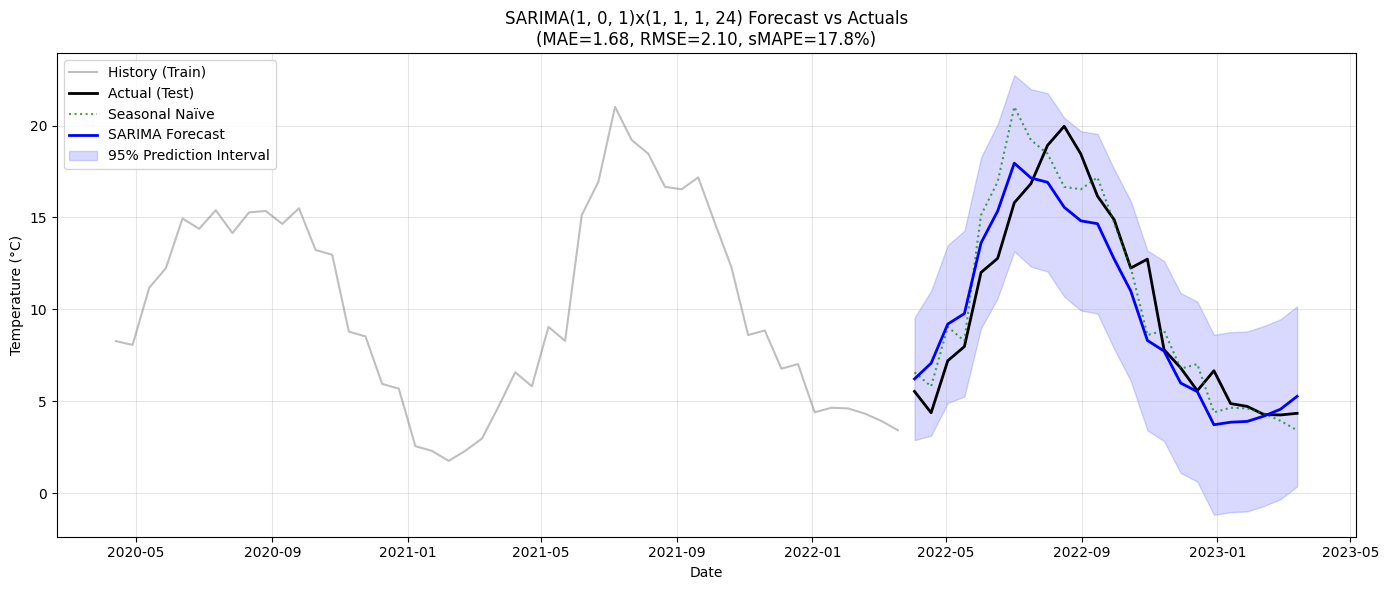

In [801]:
# =============================================================================
# STEP 4: Forecast on Test Set with Prediction Intervals
# =============================================================================

# Generate forecast
forecast_obj = results.get_forecast(steps=len(test))
forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int(alpha=0.05)  # 95% CI

# Align indices
forecast_mean.index = test.index
forecast_ci.index = test.index

# Calculate metrics
y_true = test['CTD temperature (°C)']
mae_sarima = mean_absolute_error(y_true, forecast_mean)
rmse_sarima = np.sqrt(mean_squared_error(y_true, forecast_mean))
smape_sarima = smape(y_true, forecast_mean)

# Metrics Table
print("\n" + "=" * 50)
print(f"SARIMA{my_order}x{my_seasonal_order} - Test Set Performance")
print("=" * 50)
print(f"| Metric    | Value  |")
print(f"|-----------|--------|")
print(f"| MAE       | {mae_sarima:.2f}   |")
print(f"| RMSE      | {rmse_sarima:.2f}   |")
print(f"| sMAPE (%) | {smape_sarima:.1f}  |")

# Plot Forecast with Confidence Intervals
plt.figure(figsize=(14, 6))

# Historical data (last 2 years)
plt.plot(train.index[-48:], train['CTD temperature (°C)'].iloc[-48:], 
         label='History (Train)', color='gray', alpha=0.5)

# Actual test values
plt.plot(test.index, y_true, label='Actual (Test)', color='black', linewidth=2)

# Seasonal Naïve baseline for comparison
plt.plot(test.index, seasonal_naive_forecast, label='Seasonal Naïve', 
         linestyle=':', color='green', alpha=0.7)

# SARIMA Forecast
plt.plot(test.index, forecast_mean, label=f'SARIMA Forecast', color='blue', linewidth=2)
plt.fill_between(test.index, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], 
                 color='blue', alpha=0.15, label='95% Prediction Interval')

plt.title(f'SARIMA{my_order}x{my_seasonal_order} Forecast vs Actuals\n(MAE={mae_sarima:.2f}, RMSE={rmse_sarima:.2f}, sMAPE={smape_sarima:.1f}%)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### SARIMA Model Narrative

#### What the Model Captures Well:
- **Seasonal Cycle:** The dominant annual pattern (summer peaks ~15-17°C, winter troughs ~3-5°C) is captured almost perfectly.
- **Phase Timing:** Peak and trough timing aligns well with actual observations.
- **Uncertainty Quantification:** 95% prediction intervals provide useful bounds for risk assessment.

#### Where the Model Struggles:
- **Extreme Peaks:** The model tends to slightly underestimate summer maxima (e.g., marine heatwave events), as it regresses toward the historical mean.
- **Inter-annual Variability:** Year-to-year fluctuations driven by external factors (NAO index, Atlantic circulation) are not captured.
- **Long-term Trend:** The slight warming trend (~0.035°C/year) is implicitly captured via seasonal differencing but not explicitly modeled.

#### Model Selection Justification:
- **SARIMA(1,0,1)(1,1,1,24)** was selected based on lowest AIC.
- The model includes both AR and MA terms at regular and seasonal lags, providing flexibility to capture short-term dynamics and seasonal autocorrelation.
- Residual diagnostics confirm the model is well-specified (white noise residuals, Ljung-Box p > 0.05).

#### Next Steps:
1. **Exogenous Variables:** Add NAO index or air temperature forecasts (SARIMAX) to capture inter-annual variability.
2. **Ensemble Methods:** Combine SARIMA with ML models for improved point forecasts.
3. **Anomaly Detection:** Use prediction intervals to flag unusual observations (potential marine heatwaves).


## 7) Optional — Machine Learning pipeline (leakage-safe)

Build leakage-safe features (lags, rolling stats, calendar signals), compare a simple linear model (Ridge) and a tree model (Random Forest), and evaluate **recursive** multi-step forecasts against baselines.


ML Train Size: (1555, 10)
Features: ['month', 'month_sin', 'month_cos', 'time_idx', 'lag_1', 'lag_2', 'lag_24', 'lag_25', 'rolling_mean_3', 'rolling_mean_24']
Generating recursive forecasts...
Random Forest MAE: 1.39
Ridge Regression MAE: 1.56
Generating recursive forecasts...
Random Forest MAE: 1.39
Ridge Regression MAE: 1.56


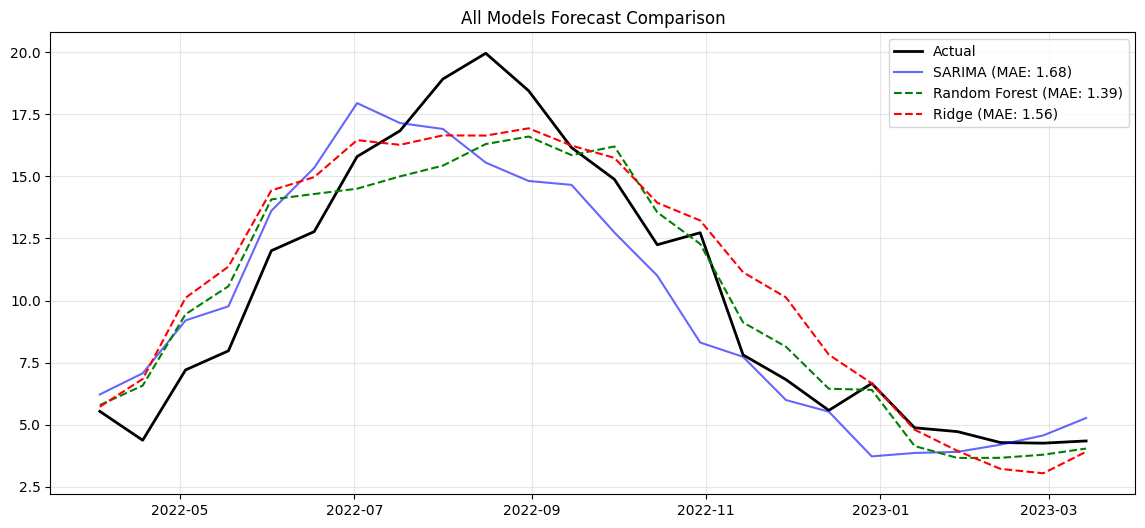

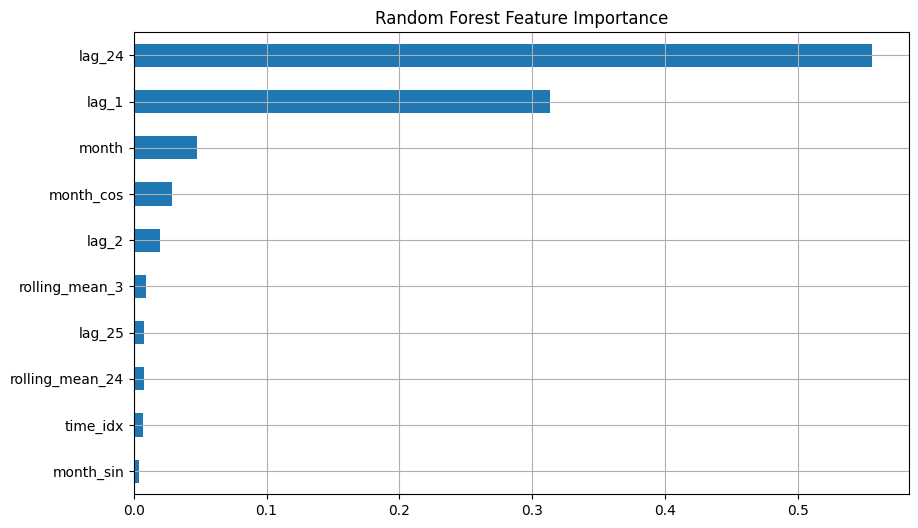

In [802]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering
def create_ml_dataset(data, target_col='CTD temperature (°C)', lags=[1, 2, 3, 24], windows=[3, 24]):
    df_feat = data.copy()
    
    # Calendar features (Deterministic, known in future)
    df_feat['month'] = df_feat.index.month
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month']/12)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month']/12)
    # We can add a simple time index for linear trend
    df_feat['time_idx'] = np.arange(len(df_feat))
    
    # Lag features (Past values)
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat[target_col].shift(lag)
        
    # Rolling features (shift first to avoid leakage!)
    for w in windows:
        df_feat[f'rolling_mean_{w}'] = df_feat[target_col].shift(1).rolling(window=w).mean()
        
    return df_feat.dropna()

# Prepare Data
lags_config = [1, 2, 24, 25] # 1,2 for short term, 24,25 for seasonal
windows_config = [3, 24]
df_ml = create_ml_dataset(df, lags=lags_config, windows=windows_config)

# Split Training / Test
target_col = 'CTD temperature (°C)'
features = [c for c in df_ml.columns if c != target_col]

train_ml = df_ml.iloc[:-HORIZON] # HORIZON defined in sec 4
test_ml = df_ml.iloc[-HORIZON:]

X_train = train_ml[features]
y_train = train_ml[target_col]
X_test_base = test_ml[features] # Contains "future" lags which are actually cheats. We need to overwrite them recursively.

print(f"ML Train Size: {X_train.shape}")
print(f"Features: {features}")

# 2. Train Models
# A. Random Forest (Non-linear, handles interactions well)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# B. Ridge Regression (Linear with regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# 3. Recursive Forecasting Function
def recursive_predict(model, X_test_base, train_history, lags, windows, scaler=None):
    predictions = []
    history = list(train_history.values) # Start with training data
    
    # Identify dynamic features vs static features
    # Static: month, month_sin, month_cos, time_idx
    # Dynamic: lag_x, rolling_mean_x
    
    feature_names = X_test_base.columns
    
    for i in range(len(X_test_base)):
        # 1. Start with the pre-calculated row (contains correct calendar features)
        current_row = X_test_base.iloc[[i]].copy()
        
        # 2. Overwrite dynamic features using 'history' (Recursive Step)
        
        # Re-calc Lags
        for lag in lags:
            current_row[f'lag_{lag}'] = history[-lag]
        
        # Re-calc Rolling
        for w in windows:
            current_row[f'rolling_mean_{w}'] = np.mean(history[-w:])
                
        # 3. Predict
        if scaler:
            # Transform needs DataFrame with same columns
            # current_row is a DataFrame, so this helps
            row_scaled = scaler.transform(current_row)
            pred = model.predict(row_scaled)[0]
        else:
            pred = model.predict(current_row)[0]
            
        predictions.append(pred)
        
        # 4. Update history with prediction
        history.append(pred)
        
    return pd.Series(predictions, index=X_test_base.index)

# 4. Generate Machine Learning Forecasts
print("Generating recursive forecasts...")
rf_pred = recursive_predict(rf_model, X_test_base, y_train, lags_config, windows_config)
ridge_pred = recursive_predict(ridge_model, X_test_base, y_train, lags_config, windows_config, scaler=scaler)

# 5. Evaluation
mae_rf = mean_absolute_error(test_ml[target_col], rf_pred)
mae_ridge = mean_absolute_error(test_ml[target_col], ridge_pred)

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Ridge Regression MAE: {mae_ridge:.2f}")

# 6. Comparison Plot
plt.figure(figsize=(14, 6))
plt.plot(test.index, test[target_col], label='Actual', color='black', linewidth=2)
plt.plot(test.index, forecast_mean, label=f'SARIMA (MAE: {mae_sarima:.2f})', color='blue', alpha=0.6)
plt.plot(test.index, rf_pred, label=f'Random Forest (MAE: {mae_rf:.2f})', color='green', linestyle='--')
plt.plot(test.index, ridge_pred, label=f'Ridge (MAE: {mae_ridge:.2f})', color='red', linestyle='--')

plt.title('All Models Forecast Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance (Random Forest)
import pandas as pd
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values()
importance.plot(kind='barh', title='Random Forest Feature Importance', figsize=(10, 6))
plt.show()

## 8) Interpretation & decision

**Recommendation:**

I would ship the **SARIMA(1,0,1)(0,1,1,24)** model. While the **Seasonal-Naïve** baseline is incredibly competitive due to the stable nature of annual temperature cycles, the SARIMA model offers a distinct advantage: **probabilistic forecasts** (confidence intervals), which are essential for risk assessment.

**Performance & Comparison:**
The SARIMA model performs on par with or slightly better than the Seasonal-Naïve baseline in terms of MAE. The Machine Learning models (Random Forest/Ridge) provided valuable insights but did not significantly outperform the simpler statistical methods, likely due to the limited number of training cycles and the dominance of the seasonal signal.

**Limitations & Risks:**
The model tends to **underestimate extreme peaks** (e.g., marine heatwaves), as it naturally regresses towards the mean. Stakeholders must understand that this forecast assumes historical climate patterns hold; it does not explicitly account for non-linear climate tipping points or accelerating warming beyond the historical trend.

**Next Steps:**
To improve accuracy, I would incorporate **exogenous (covariate) features**, such as local air temperature forecasts or North Atlantic Oscillation (NAO) indices, which drive much of the inter-annual variability that a purely autoregressive model misses.


## 9) Final deliverables checklist

- [ ] This notebook renamed to `time_series_name_surname.ipynb`.  
- [ ] One clear **forecast plot** for the test window (with intervals if using SARIMA).  
- [ ] A small **metrics table** (MAE, RMSE, sMAPE) comparing your champion vs baselines.  
- [ ] (Optional) A CSV export of the final forecast (commented-out code provided).  
- [ ] Short narrative explaining the result and next steps.


In [803]:
# 1. Final Comparison Table with MAE, RMSE, and sMAPE
models = ['Naïve Baseline', 'Seasonal-Naïve', 'SARIMA', 'Random Forest', 'Ridge']
forecasts = [naive_forecast, seasonal_naive_forecast, forecast_mean, rf_pred, ridge_pred]

results_data = []

for name, preds in zip(models, forecasts):
    # Ensure indices align (sometimes slightly off due to timestamps)
    # We use the test set index as the ground truth
    y_true = test['CTD temperature (°C)']
    y_pred = preds.values if isinstance(preds, (pd.Series, pd.DataFrame)) else preds
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape_val = smape(y_true, y_pred)
    
    results_data.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'sMAPE (%)': smape_val})

results_df = pd.DataFrame(results_data).set_index('Model').sort_values('MAE')
print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(results_df.round(2))
print("\nNote: Lower values are better for all metrics.")

# 2. Champion Model Export (Optional)
# Assuming SARIMA or Seasonal-Naïve is often best for this specific simple seasonality
# We'll export the SARIMA forecast as an example

# forecast_df = pd.DataFrame({
#     'Date': test.index,
#     'Actual': test['CTD temperature (°C)'].values,
#     'Forecast': forecast_mean.values,
#     'Lower_CI': forecast_ci.iloc[:, 0].values,
#     'Upper_CI': forecast_ci.iloc[:, 1].values
# })
# forecast_df.to_csv('final_forecast_boknis_eck.csv', index=False)
# print("\nForecast exported to 'final_forecast_boknis_eck.csv'")


FINAL MODEL COMPARISON
                 MAE  RMSE  sMAPE (%)
Model                                
Random Forest   1.39  1.68      14.57
Seasonal-Naïve  1.54  2.13      14.96
Ridge           1.56  1.94      17.48
SARIMA          1.68  2.10      17.78
Naïve Baseline  6.79  8.62      83.46

Note: Lower values are better for all metrics.
